In [1]:
import os

os.chdir('MultiBench')

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load MOSI dataset
with open('data/mosi_raw.pkl', 'rb') as f:
    mosi_data = pickle.load(f)

# Basic info
modalities = ['text', 'vision', 'audio']
splits = ['train', 'valid', 'test']

print("=" * 80)
print("CMU-MOSI DATASET ANALYSIS")
print("=" * 80)

print("\n1. DATASET SPLITS:")
print("-" * 80)
for split in splits:
    n_samples = mosi_data[split]['text'].shape[0]
    print(f"   {split.upper():<10}: {n_samples:>5} samples")

print(f"\n   TOTAL:      {sum([mosi_data[s]['text'].shape[0] for s in splits]):>5} samples")

print("\n2. MODALITIES:")
print("-" * 80)
print(f"   Number of Modalities: {len(modalities)}")
for i, mod in enumerate(modalities, 1):
    features = mosi_data['train'][mod].shape[2]
    seq_len = mosi_data['train'][mod].shape[1]
    print(f"   {i}. {mod.upper():<10} - {features:>3} features, {seq_len} timesteps")

print("\n3. SENTIMENT CLASSES:")
print("-" * 80)
print("   Representation: Continuous scores from -3 (very negative) to +3 (very positive)")
print("   7 Sentiment Classes:")
print("      -3: Highly Negative")
print("      -2: Negative") 
print("      -1: Weakly Negative")
print("       0: Neutral")
print("      +1: Weakly Positive")
print("      +2: Positive")
print("      +3: Highly Positive")
print("\n   Note: Each modality (text, vision, audio) shares the SAME sentiment labels")

CMU-MOSI DATASET ANALYSIS

1. DATASET SPLITS:
--------------------------------------------------------------------------------
   TRAIN     :  1283 samples
   VALID     :   214 samples
   TEST      :   686 samples

   TOTAL:       2183 samples

2. MODALITIES:
--------------------------------------------------------------------------------
   Number of Modalities: 3
   1. TEXT       - 300 features, 50 timesteps
   2. VISION     -  35 features, 50 timesteps
   3. AUDIO      -  74 features, 50 timesteps

3. SENTIMENT CLASSES:
--------------------------------------------------------------------------------
   Representation: Continuous scores from -3 (very negative) to +3 (very positive)
   7 Sentiment Classes:
      -3: Highly Negative
      -2: Negative
      -1: Weakly Negative
       0: Neutral
      +1: Weakly Positive
      +2: Positive
      +3: Highly Positive

   Note: Each modality (text, vision, audio) shares the SAME sentiment labels


In [4]:
# Detailed statistics for each modality
print("\n4. MODALITY DETAILS:")
print("=" * 80)
print(f"{'MODALITY':<12} {'TRAIN':<8} {'VALID':<8} {'TEST':<8} {'FEATURES':<10} {'SEQ_LEN':<10}")
print("-" * 80)

for modality in modalities:
    train_shape = mosi_data['train'][modality].shape
    valid_shape = mosi_data['valid'][modality].shape
    test_shape = mosi_data['test'][modality].shape
    
    print(f"{modality.upper():<12} {train_shape[0]:<8} {valid_shape[0]:<8} {test_shape[0]:<8} "
          f"{train_shape[2]:<10} {train_shape[1]:<10}")

print("\n5. SENTIMENT CLASS DISTRIBUTION:")
print("=" * 80)

# Analyze sentiment distribution
for split in splits:
    labels = mosi_data[split]['labels'].flatten()
    print(f"\n{split.upper()}:")
    
    sentiment_counts = {}
    for sentiment in range(-3, 4):
        # Count labels in range [sentiment-0.5, sentiment+0.5]
        count = int(np.sum((labels > sentiment - 0.5) & (labels <= sentiment + 0.5)))
        sentiment_counts[sentiment] = count
        
    for sentiment, count in sentiment_counts.items():
        percentage = (count / len(labels)) * 100
        print(f"   Sentiment {sentiment:+2d}: {count:>4} samples ({percentage:>5.1f}%)")
    
    print(f"   Range: [{labels.min():.2f}, {labels.max():.2f}], Mean: {labels.mean():.2f}")


4. MODALITY DETAILS:
MODALITY     TRAIN    VALID    TEST     FEATURES   SEQ_LEN   
--------------------------------------------------------------------------------
TEXT         1283     214      686      300        50        
VISION       1283     214      686      35         50        
AUDIO        1283     214      686      74         50        

5. SENTIMENT CLASS DISTRIBUTION:

TRAIN:
   Sentiment -3:   25 samples (  1.9%)
   Sentiment -2:  198 samples ( 15.4%)
   Sentiment -1:  241 samples ( 18.8%)
   Sentiment +0:  233 samples ( 18.2%)
   Sentiment +1:  229 samples ( 17.8%)
   Sentiment +2:  311 samples ( 24.2%)
   Sentiment +3:   46 samples (  3.6%)
   Range: [-3.00, 3.00], Mean: 0.23

VALID:
   Sentiment -3:    8 samples (  3.7%)
   Sentiment -2:   25 samples ( 11.7%)
   Sentiment -1:   26 samples ( 12.1%)
   Sentiment +0:   48 samples ( 22.4%)
   Sentiment +1:   39 samples ( 18.2%)
   Sentiment +2:   49 samples ( 22.9%)
   Sentiment +3:   19 samples (  8.9%)
   Range: [-3.00,

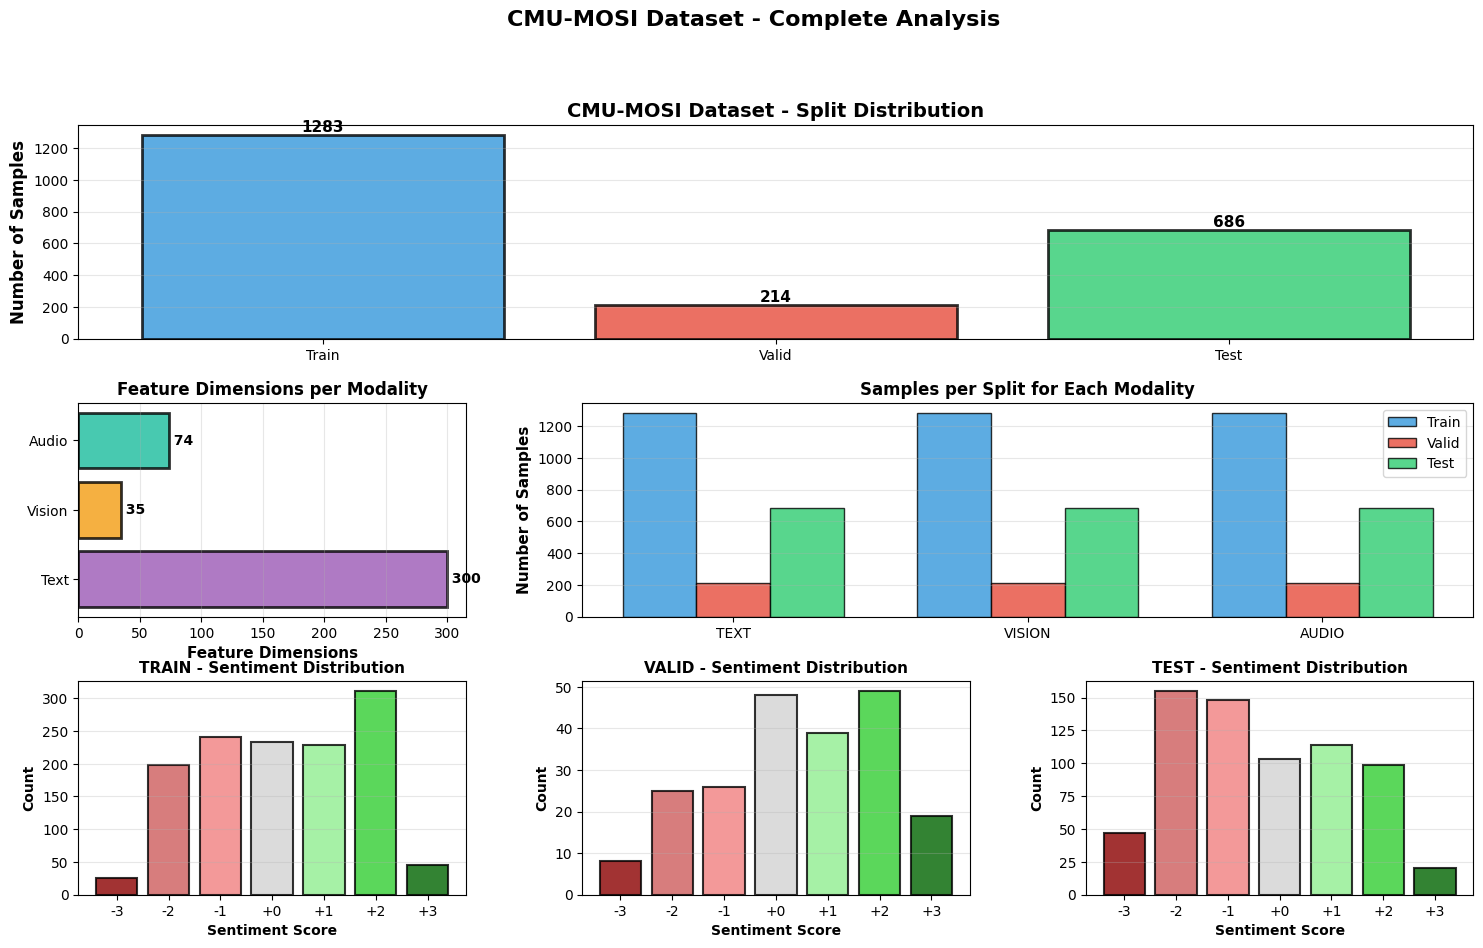

In [6]:
# Comprehensive Visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Dataset Split Distribution
ax1 = fig.add_subplot(gs[0, :])
split_names = ['Train', 'Valid', 'Test']
split_counts = [mosi_data[s.lower()]['text'].shape[0] for s in split_names]
colors_split = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax1.bar(split_names, split_counts, color=colors_split, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('CMU-MOSI Dataset - Split Distribution', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, split_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{count}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Modality Feature Dimensions
ax2 = fig.add_subplot(gs[1, 0])
mod_names = ['Text', 'Vision', 'Audio']
mod_features = [mosi_data['train'][m].shape[2] for m in modalities]
colors_mod = ['#9b59b6', '#f39c12', '#1abc9c']
bars = ax2.barh(mod_names, mod_features, color=colors_mod, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_xlabel('Feature Dimensions', fontsize=11, fontweight='bold')
ax2.set_title('Feature Dimensions per Modality', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars, mod_features)):
    ax2.text(val, i, f' {val}', va='center', fontsize=10, fontweight='bold')

# 3. Samples per Modality per Split
ax3 = fig.add_subplot(gs[1, 1:])
x = np.arange(len(modalities))
width = 0.25
train_counts = [mosi_data['train'][m].shape[0] for m in modalities]
valid_counts = [mosi_data['valid'][m].shape[0] for m in modalities]
test_counts = [mosi_data['test'][m].shape[0] for m in modalities]

ax3.bar(x - width, train_counts, width, label='Train', color='#3498db', alpha=0.8, edgecolor='black')
ax3.bar(x, valid_counts, width, label='Valid', color='#e74c3c', alpha=0.8, edgecolor='black')
ax3.bar(x + width, test_counts, width, label='Test', color='#2ecc71', alpha=0.8, edgecolor='black')
ax3.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax3.set_title('Samples per Split for Each Modality', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([m.upper() for m in modalities])
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# 4-6. Sentiment Class Distribution (7 classes) for each split
sentiments = list(range(-3, 4))
colors_sent = ['#8b0000', '#cd5c5c', '#f08080', '#d3d3d3', '#90ee90', '#32cd32', '#006400']
split_positions = [(2, 0), (2, 1), (2, 2)]

for idx, (split, pos) in enumerate(zip(splits, split_positions)):
    ax = fig.add_subplot(gs[pos[0], pos[1]])
    labels = mosi_data[split]['labels'].flatten()
    
    counts = []
    for sentiment in sentiments:
        count = int(np.sum((labels > sentiment - 0.5) & (labels <= sentiment + 0.5)))
        counts.append(count)
    
    bars = ax.bar(sentiments, counts, color=colors_sent, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Sentiment Score', fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax.set_title(f'{split.upper()} - Sentiment Distribution', fontsize=11, fontweight='bold')
    ax.set_xticks(sentiments)
    ax.set_xticklabels([f'{s:+d}' for s in sentiments])
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('CMU-MOSI Dataset - Complete Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## Dataset Structure Explanation

**CMU-MOSI (Multimodal Opinion Sentiment Intensity)**

**Structure:**
- **Multimodal**: All 3 modalities (text, vision, audio) are temporally aligned
- **Synchronized**: Each sample has the same timestamp across all modalities
- **Same Labels**: All modalities share identical sentiment labels

**Labeling Scheme:**
- **Type**: Continuous sentiment scores (not discrete classes)
- **Range**: -3 (highly negative) to +3 (highly positive)
- **7 Sentiment Levels**: Can be discretized into 7 classes for classification tasks

**How Sentiment is Represented:**
- **Numerically**: Float values between -3.0 and +3.0
- **Categorically**: Can be binned into 7 classes (-3, -2, -1, 0, +1, +2, +3)
- **Binary**: Can be simplified to Positive (>0) vs Non-positive (≤0)

In [7]:
# Export modalities
def export_modality(modality_name, output_path='data/exported_modalities'):
    import os
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    modality_data = {
        'train': {'data': mosi_data['train'][modality_name], 'labels': mosi_data['train']['labels']},
        'valid': {'data': mosi_data['valid'][modality_name], 'labels': mosi_data['valid']['labels']},
        'test': {'data': mosi_data['test'][modality_name], 'labels': mosi_data['test']['labels']}
    }
    
    output_file = os.path.join(output_path, f'mosi_{modality_name}.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump(modality_data, f)
    
    print(f"✓ {modality_name.upper()}: {output_file}")
    return modality_data

# Export all modalities
print("Exporting modalities...")
for modality in modalities:
    export_modality(modality)
print("\nDone! Files saved in: data/exported_modalities/")

Exporting modalities...
✓ TEXT: data/exported_modalities\mosi_text.pkl
✓ VISION: data/exported_modalities\mosi_vision.pkl
✓ AUDIO: data/exported_modalities\mosi_audio.pkl

Done! Files saved in: data/exported_modalities/
✓ TEXT: data/exported_modalities\mosi_text.pkl
✓ VISION: data/exported_modalities\mosi_vision.pkl
✓ AUDIO: data/exported_modalities\mosi_audio.pkl

Done! Files saved in: data/exported_modalities/
